# Transient Percolation Zone Analysis

This notebook explores how the **percolation zone** has migrated over the course of the IMAU-FDM simulation by analysing annual surface melt and runoff events at each grid point.

Three analyses are available for **any registered variable** (currently `surfmelt` and `Runoff`):

1. **Event frequency map** — how many years did each pixel exceed the annual threshold? Covers either the full simulation or a user-defined trailing window.
2. **Event frequency histogram** — side-by-side comparison of the per-pixel event count distribution between two time periods.
3. **Zone migration map** — classify each pixel as low-event or high-event in an early and a late window, then map which pixels have transitioned.

All defaults (paths, thresholds, windows) live in `config.py` and can be overridden inline in any cell.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, '.')
import config
from transient_percolation_analysis import (
    map_melt_frequency,
    plot_melt_histogram,
    plot_percolation_migration,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12

## Configuration

Edit `config.py` to change paths and defaults.  
All function arguments below can also be overridden inline without touching the config file.

In [5]:
# Confirm the variable files exist before running the analyses
for var, path in config.VARIABLE_FILES.items():
    status = '✓' if path.exists() else '✗  NOT FOUND'
    print(f'  [{status}]  {var:10s}  {path.name}')

print(f'\nEvent thresholds : {config.EVENT_THRESHOLDS}')
print(f'Period 1 / 2     : {config.PERIOD_1}  /  {config.PERIOD_2}')
print(f'Early / late win : {config.EARLY_WINDOW}  /  {config.LATE_WINDOW}')
print(f'Dry / perc limit : ≤{config.DRY_EVENTS_MAX}  /  ≥{config.PERCOLATION_EVENTS_MIN} event years')

  [✓]  surfmelt    FDM_surfmelt_FGRN055_1939-2023_10day.nc
  [✓]  Runoff      FDM_Runoff_FGRN055_1939-2023_10day.nc
  [✓]  vacc        FDM_vacc_FGRN055_1939-2023_10day.nc
  [✓]  refreeze    FDM_refreeze_FGRN055_1939-2023_10day.nc
  [✓]  vsub        FDM_vsub_FGRN055_1939-2023_10day.nc

Event thresholds : {'surfmelt': 10.0, 'Runoff': 10.0}
Period 1 / 2     : (1940, 1970)  /  (1993, 2023)
Early / late win : (1940, 1963)  /  (2000, 2023)
Dry / perc limit : ≤0  /  ≥1 event years


---
## Surface melt analyses

### Analysis 1 – Event frequency map

Each pixel is coloured by how many years its annual surface melt exceeded
`config.EVENT_THRESHOLDS['surfmelt']` (default 10 mm w.e.).

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.141965.20260303_063947.225/ipykernel_2065288/3201866223.py:3: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


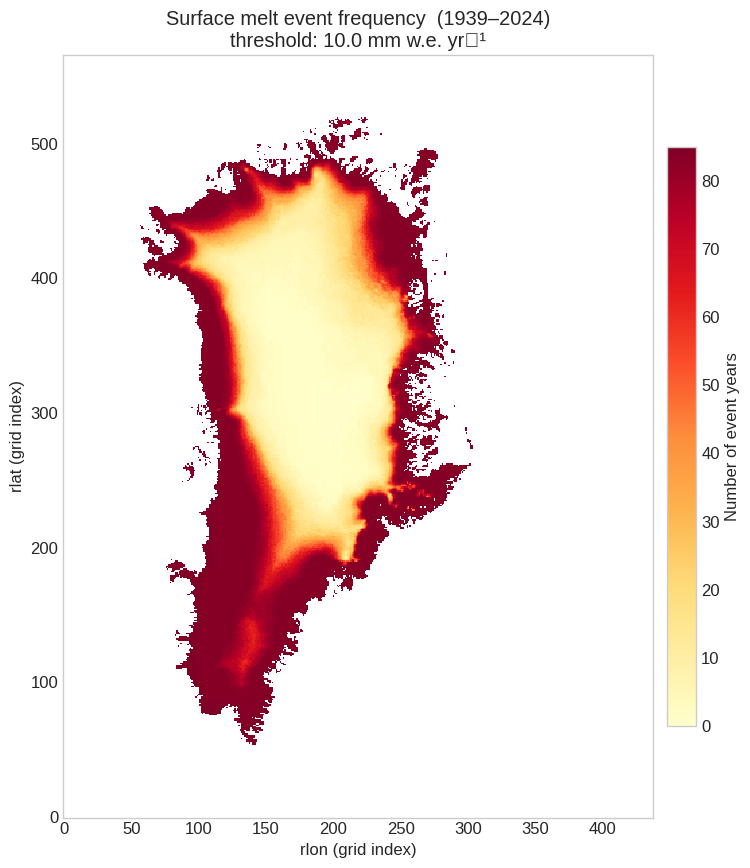

In [ ]:
# 1a. All years in the simulation
count_all, ax = map_melt_frequency()
plt.tight_layout()
plt.show()

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.3877184.20260226_132541.455/ipykernel_1375644/3224612978.py:5: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


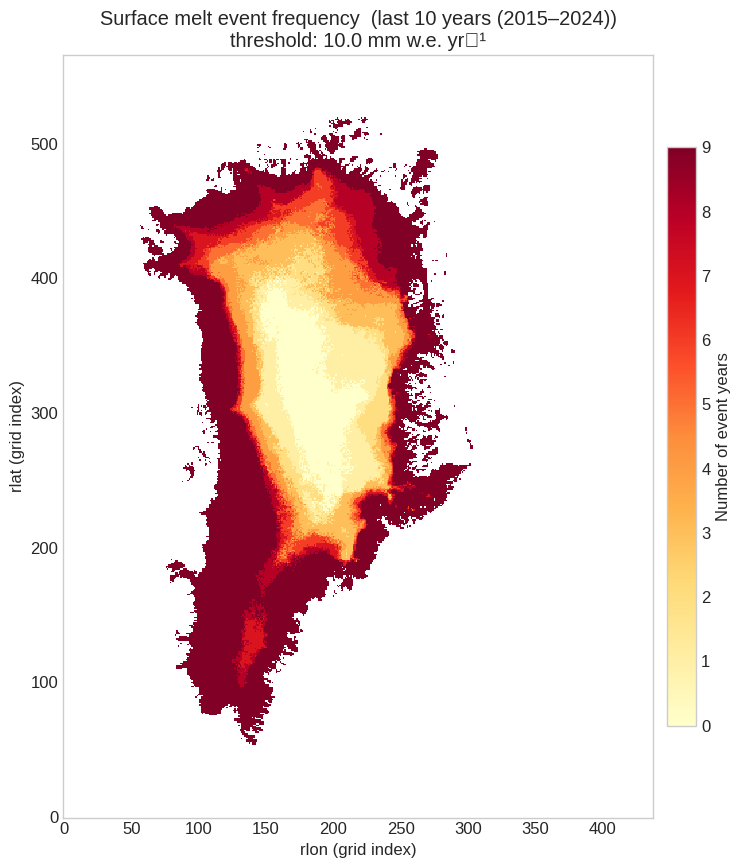

In [6]:
# 1b. Last N years only – change years_back to taste
YEARS_BACK = 10

count_recent, ax = map_melt_frequency(years_back=YEARS_BACK)
plt.tight_layout()
plt.show()

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.3877184.20260226_132541.455/ipykernel_1375644/3716777093.py:7: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


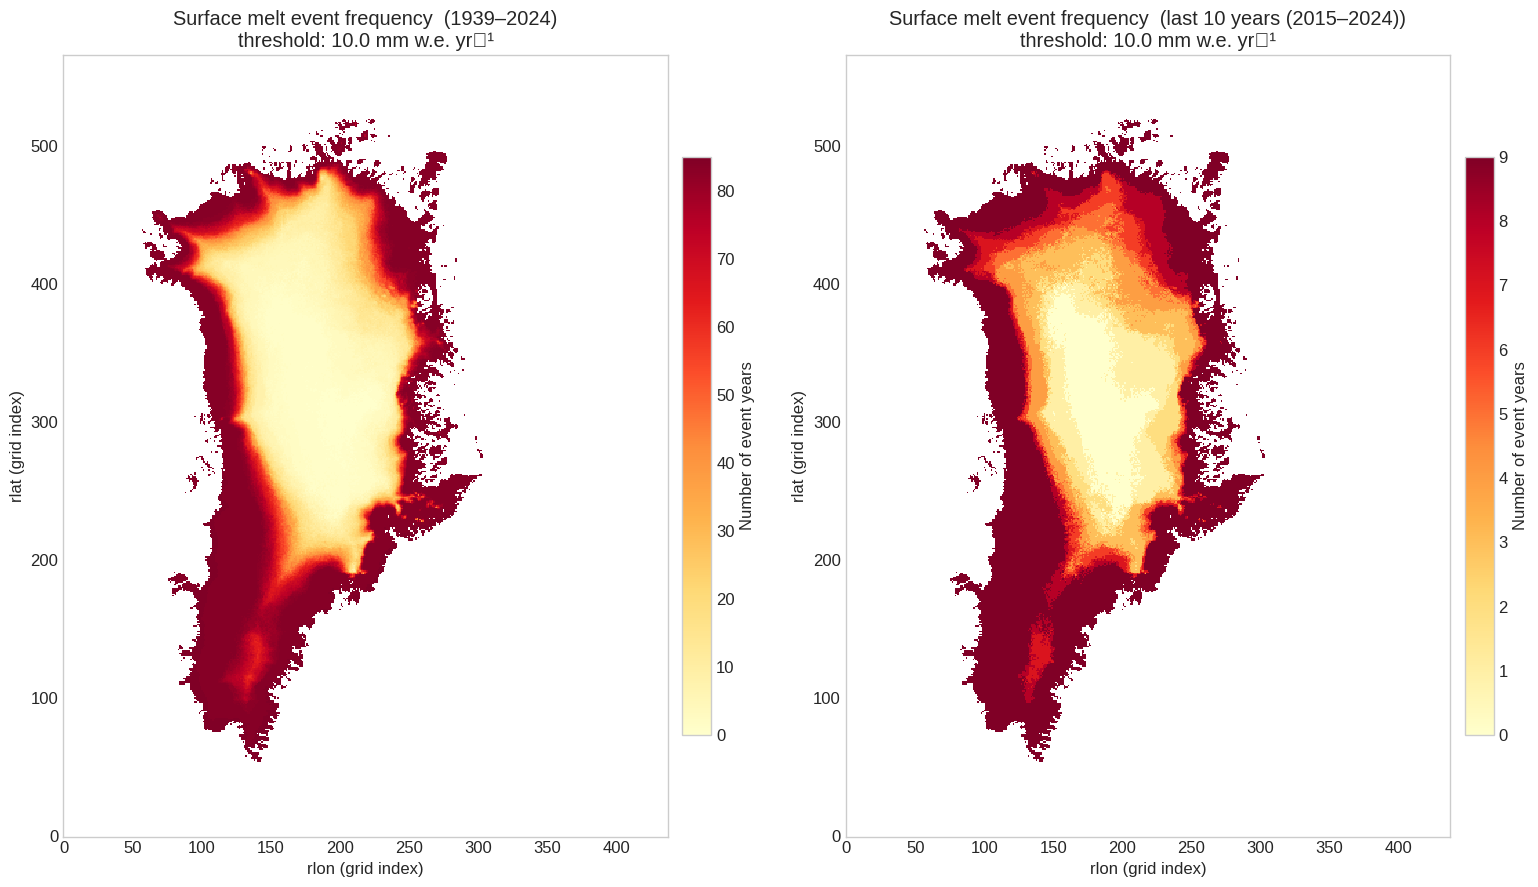

In [7]:
# 1c. Side-by-side: full simulation vs. last N years
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

map_melt_frequency(ax=axes[0])
map_melt_frequency(years_back=YEARS_BACK, ax=axes[1])

plt.tight_layout()
plt.show()

### Analysis 2 – Period comparison histogram

Grouped bar chart showing how the distribution of per-pixel surface melt event counts has
changed between two periods.  A rightward shift in the later period indicates more
widespread or more frequent melt.

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.3877184.20260226_132541.455/ipykernel_1375644/279504554.py:3: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


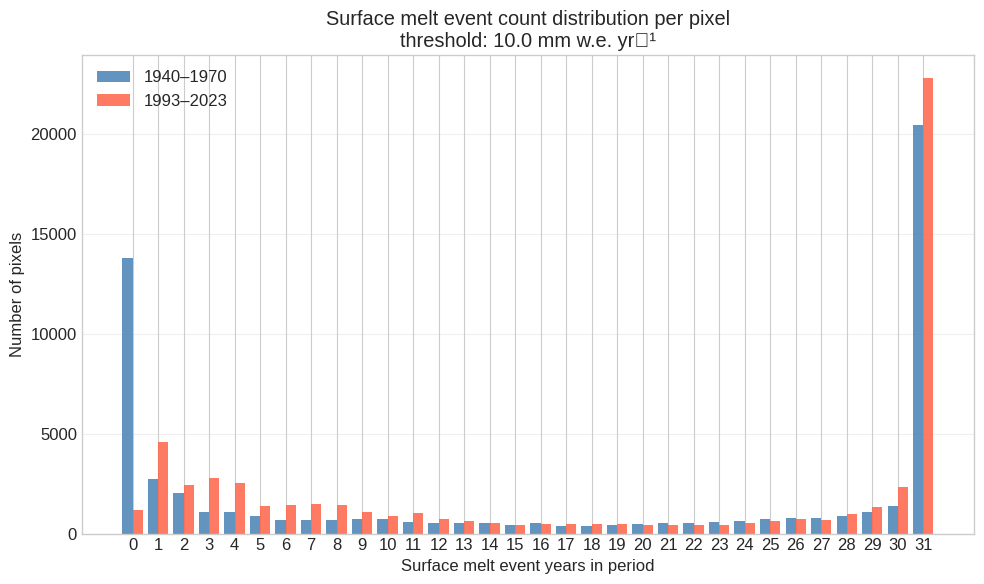

In [8]:
# Uses config.PERIOD_1 and config.PERIOD_2 by default
ax = plot_melt_histogram()
plt.tight_layout()
plt.show()

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.3433190.20260226_074951.083/ipykernel_3844282/1260799531.py:6: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


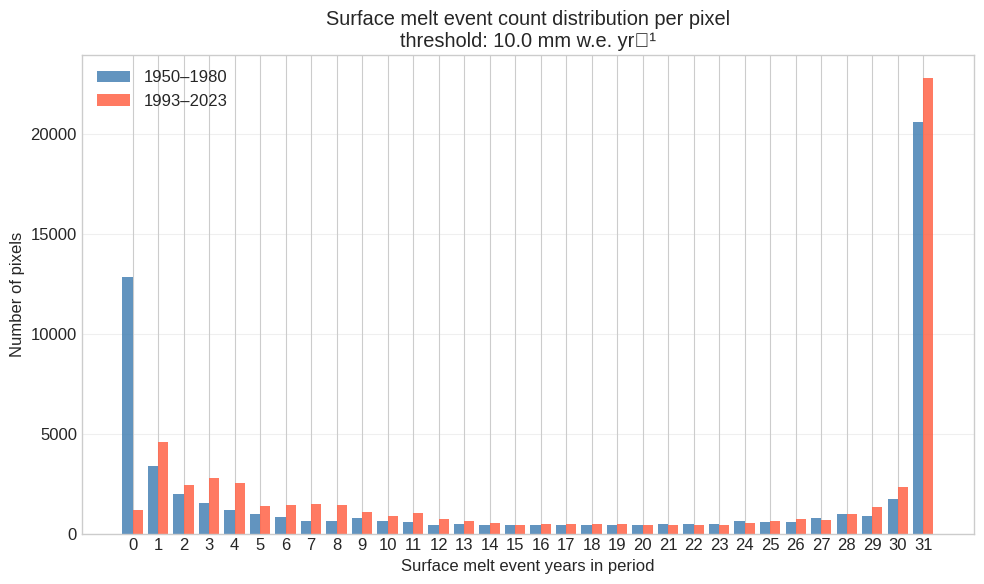

In [ ]:
# Custom periods – override inline
ax = plot_melt_histogram(
    period1=(1950, 1980),
    period2=(1993, 2023),
)
plt.tight_layout()
plt.show()

### Analysis 3 – Percolation zone migration map

Compares each pixel's surface melt event count in an **early window** against a **late window**.
Pixels with ≤ `DRY_EVENTS_MAX` event years are classed as dry facies; pixels with
≥ `PERCOLATION_EVENTS_MIN` event years are classed as percolation zone.

| Colour | Category |
|--------|----------|
| Blue   | Remained dry facies in both windows |
| Orange | Remained in the percolation zone in both windows |
| **Red** | **Expanded: dry → percolation** ← main signal |
| Purple | Contracted: percolation → dry |
| White  | Off-ice, or ambiguous (event count falls between the two thresholds) |

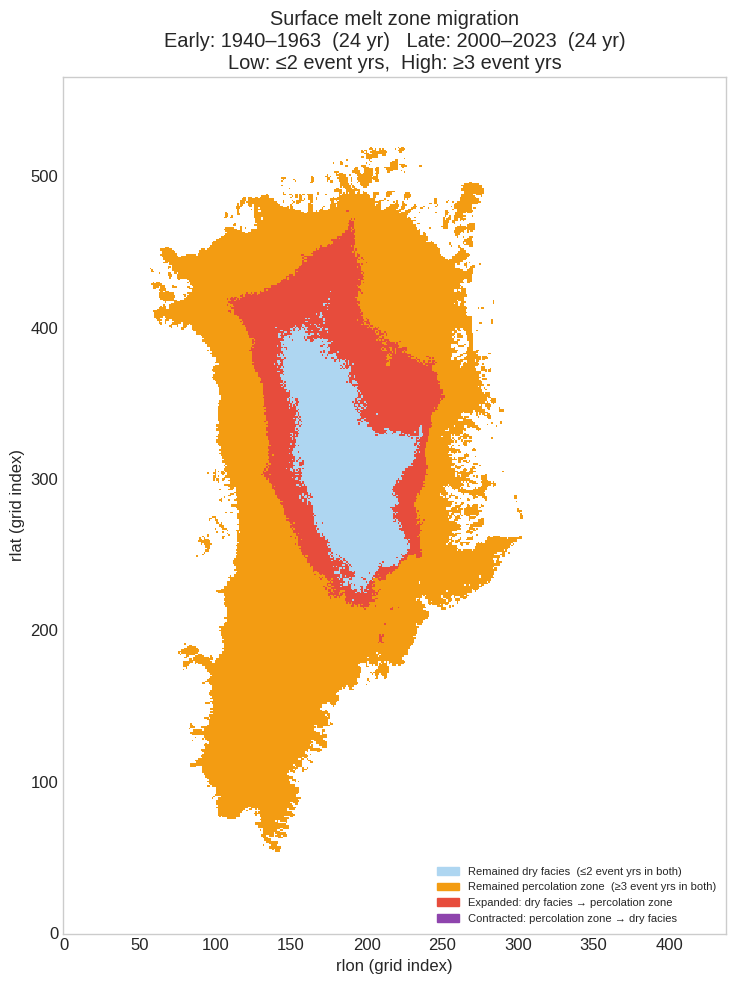

In [ ]:
# Uses config defaults (EARLY_WINDOW, LATE_WINDOW, DRY_EVENTS_MAX, PERCOLATION_EVENTS_MIN)
classification, ax = plot_percolation_migration()
plt.tight_layout()
plt.show()

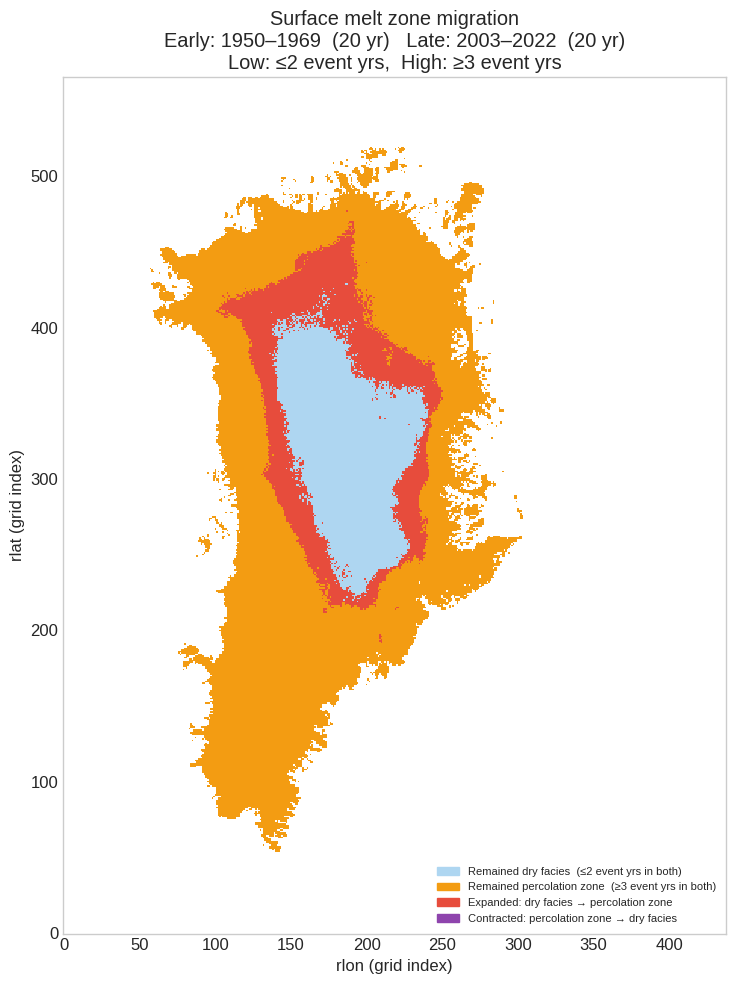

In [ ]:
# Custom windows and thresholds
classification, ax = plot_percolation_migration(
    early_window=(1950, 1969),
    late_window=(2003, 2022),
    dry_events_max=2,
    percolation_events_min=3,
)
plt.tight_layout()
plt.show()

#### Mode comparison: event-count vs. melt-amount threshold

`mode='amount'` classifies each pixel by its **mean annual melt** over the window,
split at a single `melt_threshold` (mm w.e. yr⁻¹).  No ambiguous zone.

`mode='events'` (default) counts how many years melt exceeded an annual threshold.

In [ ]:
# Side-by-side: event-count mode vs. melt-amount mode
# Adjust MELT_THRESHOLD to taste (mm w.e. mean annual melt separating dry from percolation)
MELT_THRESHOLD = 200.0  # mm w.e. yr⁻¹

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

plot_percolation_migration(
    mode='events',
    ax=axes[0],
)
axes[0].set_title(axes[0].get_title())  # already set inside the function

plot_percolation_migration(
    mode='amount',
    melt_threshold=MELT_THRESHOLD,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

In [ ]:
# How many pixels transitioned in each category?
import numpy as np

labels = {
    1: 'Remained dry',
    2: 'Remained percolation',
    3: 'Expanded (dry → percolation)',
    4: 'Contracted (percolation → dry)',
}
for cat, label in labels.items():
    n = int((classification == cat).sum())
    print(f'  {label:35s}: {n:6d} pixels')

  Remained dry                       :  10921 pixels
  Remained percolation               :  37810 pixels
  Expanded (dry → percolation)       :   9534 pixels
  Contracted (percolation → dry)     :      0 pixels


---
## Combined figure

All three analyses in one overview figure.

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.3433190.20260226_074951.083/ipykernel_3844282/159278603.py:15: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


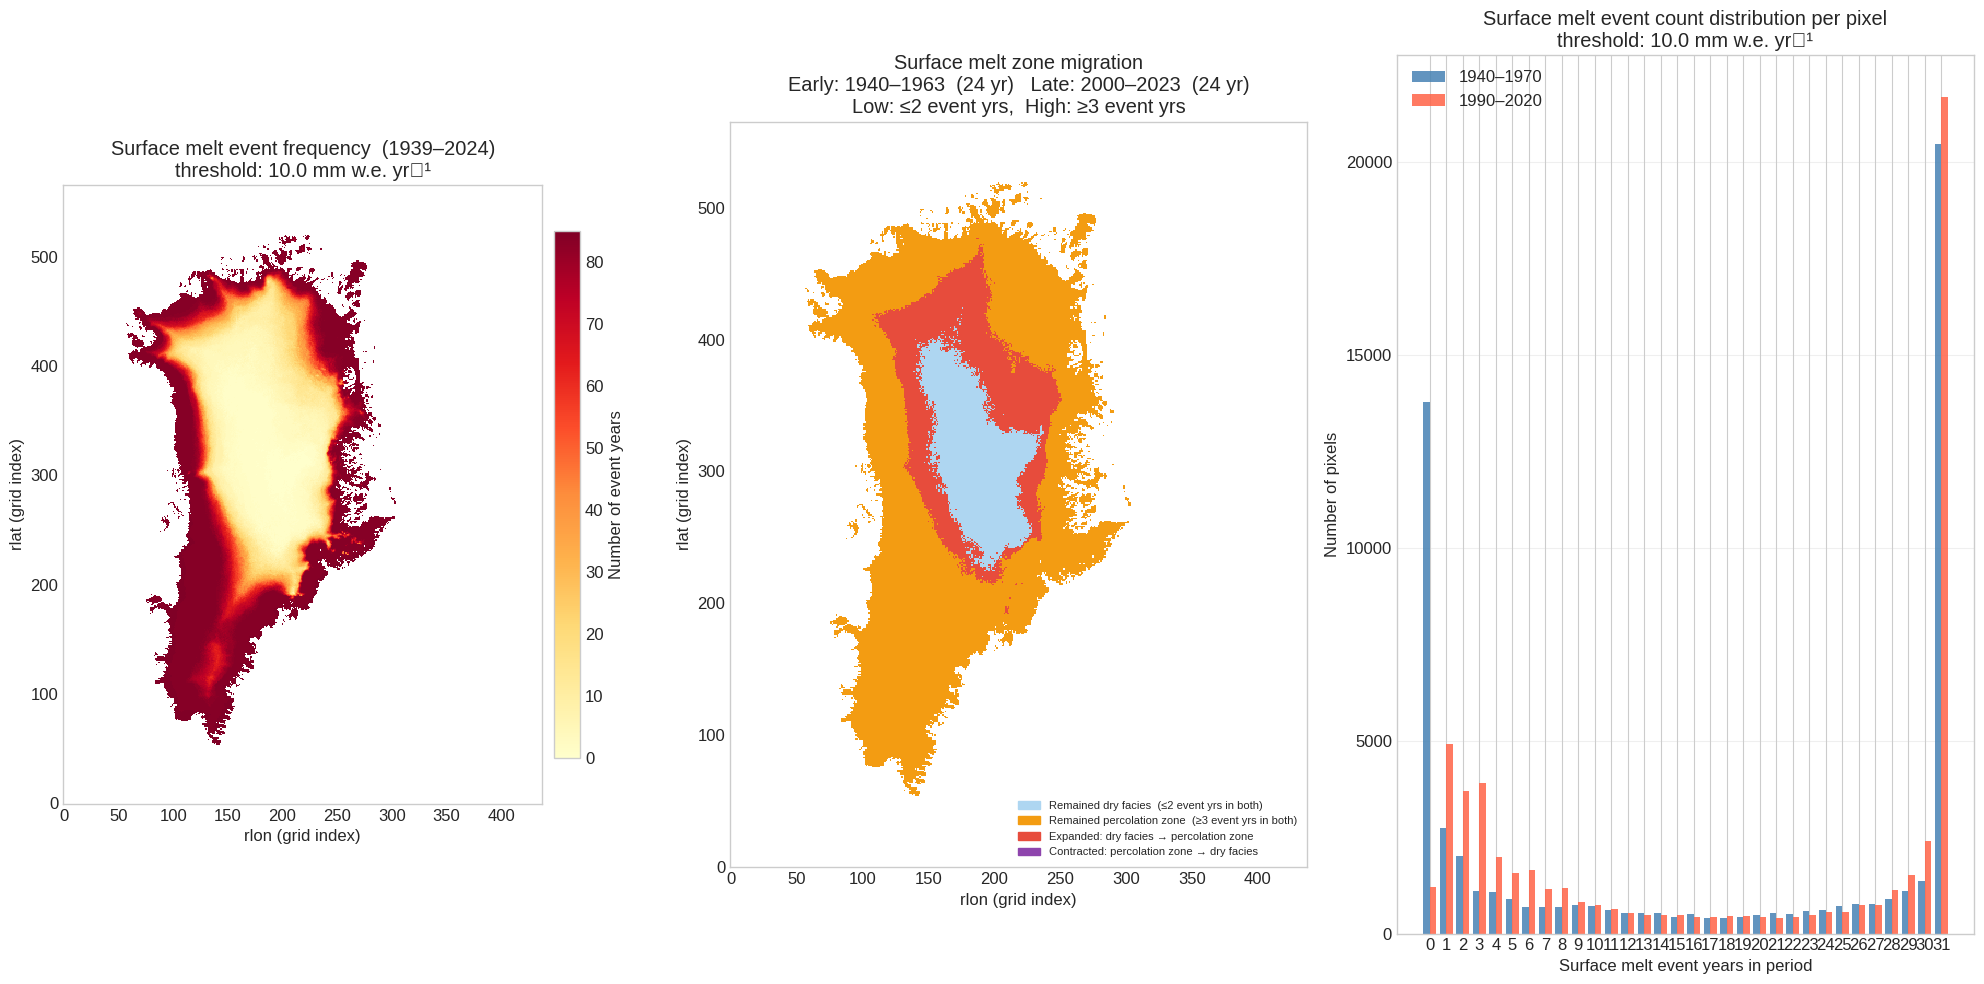

In [ ]:
fig = plt.figure(figsize=(20, 10))

# Left: melt frequency (all time)
ax1 = fig.add_subplot(1, 3, 1)
map_melt_frequency(ax=ax1)

# Middle: percolation migration
ax2 = fig.add_subplot(1, 3, 2)
plot_percolation_migration(ax=ax2)

# Right: histogram
ax3 = fig.add_subplot(1, 3, 3)
plot_melt_histogram(ax=ax3)

plt.tight_layout()
plt.show()

---
## Runoff analyses

The same three analyses repeated for **runoff** (`variable='Runoff'`).

The event threshold for runoff is set separately in `config.EVENT_THRESHOLDS['Runoff']`
(default 1.0 mm w.e. yr⁻¹) and can be overridden inline with `threshold=`.

### Analysis 1 – Event frequency map

Each pixel is coloured by how many years its annual runoff exceeded
`config.EVENT_THRESHOLDS['Runoff']` (default 1 mm w.e.).

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.3433190.20260226_074951.083/ipykernel_3844282/1851943333.py:7: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


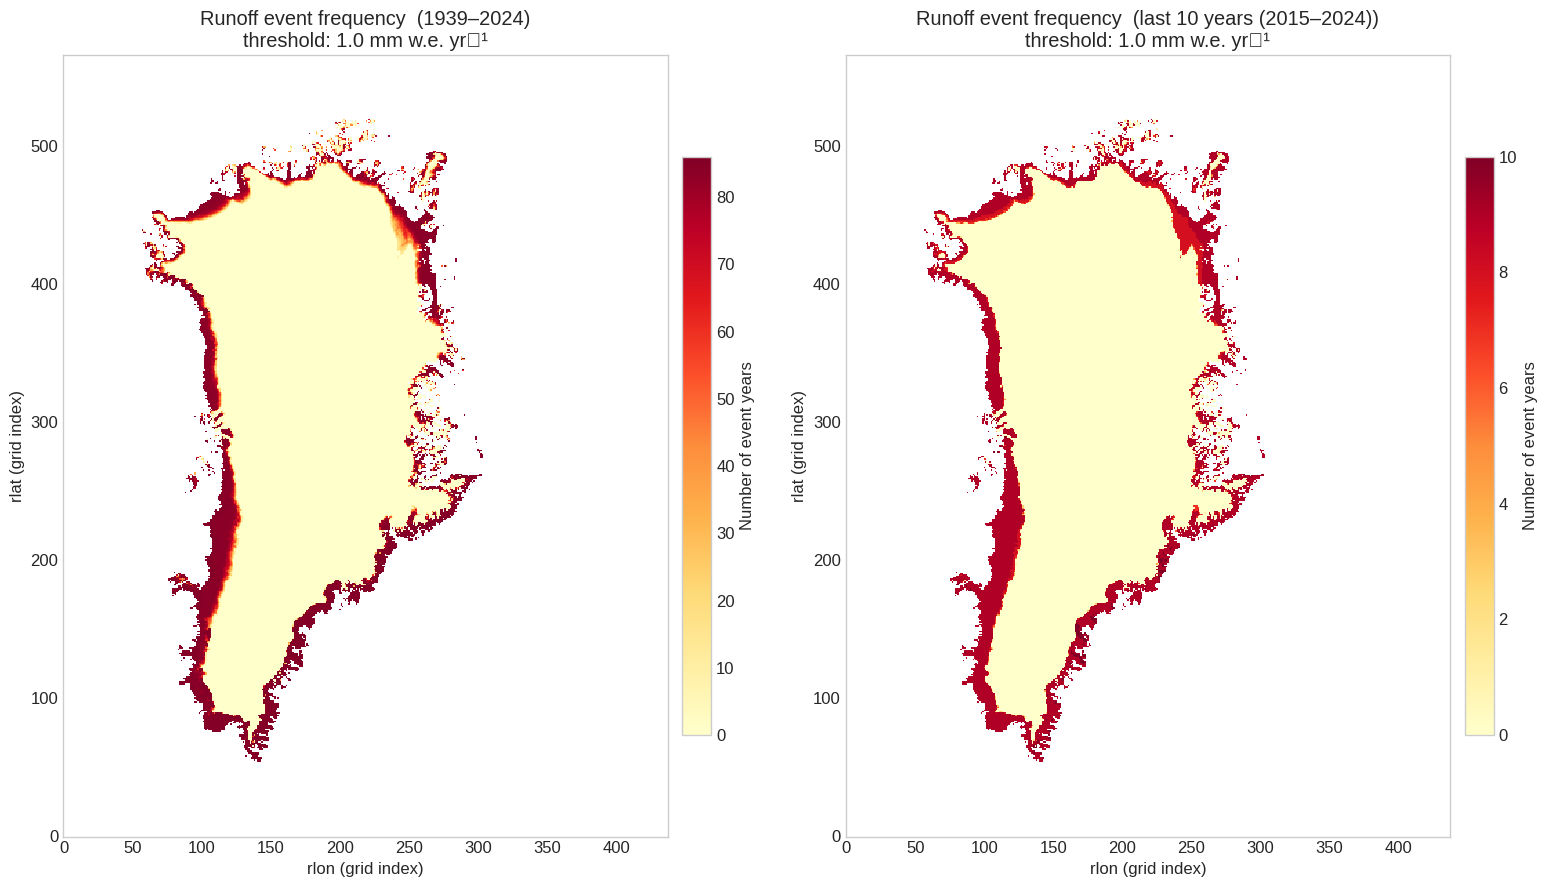

In [ ]:
# Side-by-side: full simulation and last 10 years
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

map_melt_frequency(variable='Runoff', ax=axes[0])
map_melt_frequency(variable='Runoff', years_back=10, ax=axes[1])

plt.tight_layout()
plt.show()

### Analysis 2 – Period comparison histogram

Grouped bar chart comparing runoff event counts between the two configured periods.

/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.3433190.20260226_074951.083/ipykernel_3844282/2824028353.py:3: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


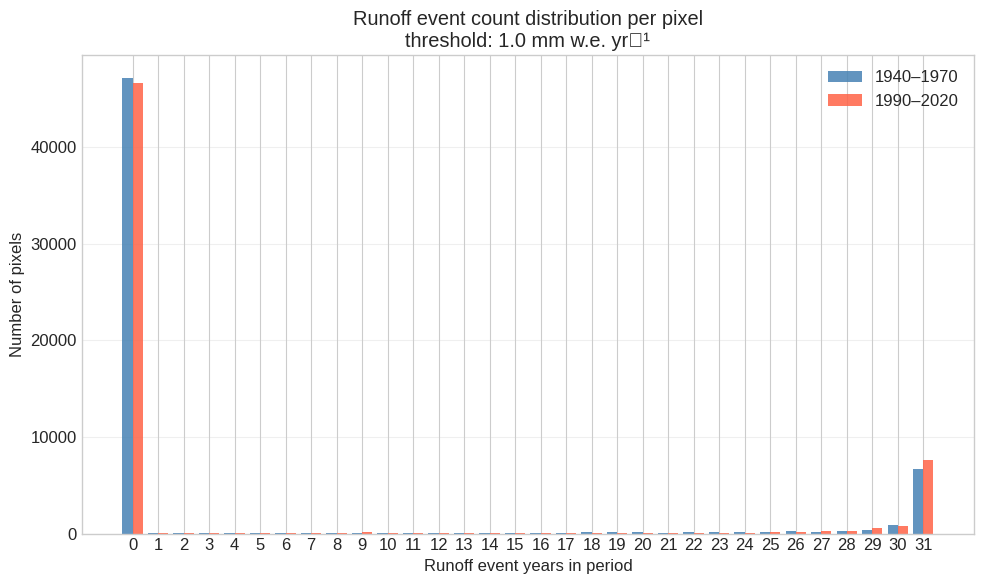

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_melt_histogram(variable='Runoff', ax=ax)
plt.tight_layout()
plt.show()

### Analysis 3 – Zone migration map

Pixels with ≤ `DRY_EVENTS_MAX` runoff event years are classed as low-runoff;
pixels with ≥ `PERCOLATION_EVENTS_MIN` are classed as high-runoff.

| Colour | Category |
|--------|----------|
| Blue   | Remained low runoff in both windows |
| Orange | Remained high runoff in both windows |
| **Red** | **Expanded: low → high runoff** |
| Purple | Contracted: high → low runoff |

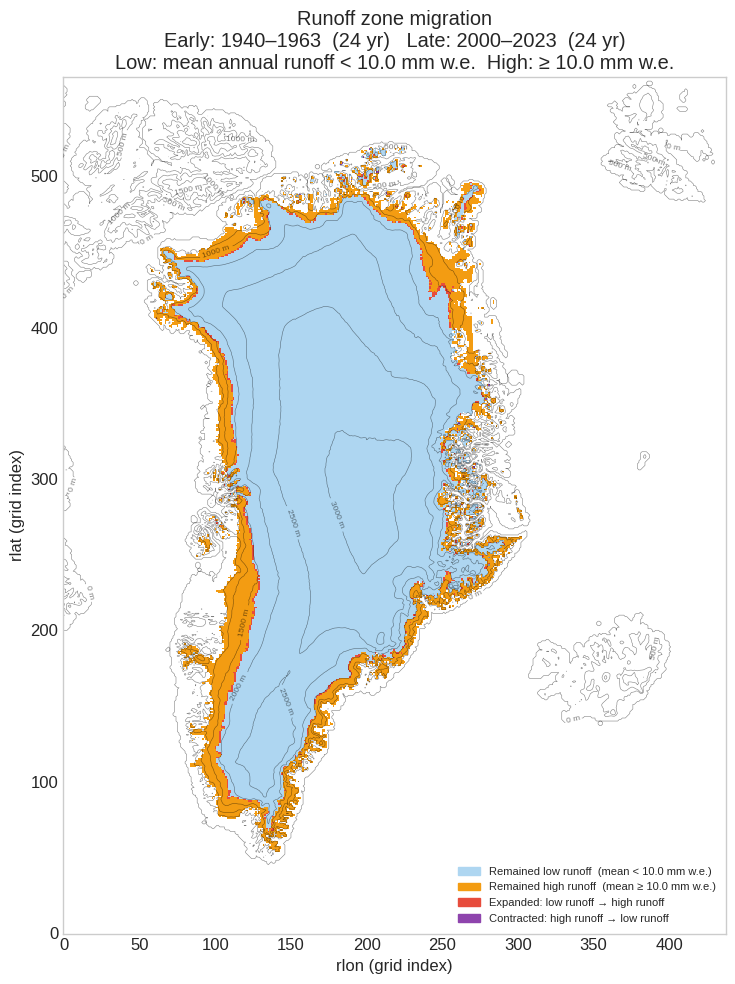

  Remained low runoff  (< 10.0 mm w.e.)             :  46563 pixels
  Remained high runoff  (≥ 10.0 mm w.e.)            :  10849 pixels
  Expanded: low → high runoff                       :    831 pixels
  Contracted: high → low runoff                     :     22 pixels


In [5]:
RUNOFF_THRESHOLD = 10.0   # mm w.e. — cells above this are "high runoff zone"

fig, ax = plt.subplots(figsize=(8, 10))
classification_runoff, ax = plot_percolation_migration(
    variable='Runoff',
    mode='amount',
    melt_threshold=RUNOFF_THRESHOLD,
    topo_contour_interval=500,
    ax=ax,
)
plt.tight_layout()
#ax.set_title("Change in runoff zone (10 mm w.e.)")
plt.show()

# Pixel counts per category
labels = {
    1: f'Remained low runoff  (< {RUNOFF_THRESHOLD} mm w.e.)',
    2: f'Remained high runoff  (≥ {RUNOFF_THRESHOLD} mm w.e.)',
    3: 'Expanded: low → high runoff',
    4: 'Contracted: high → low runoff',
}
for cat, label in labels.items():
    n = int((classification_runoff == cat).sum())
    print(f'  {label:50s}: {n:6d} pixels')

### Side-by-side comparison: surfmelt vs runoff migration

/etc/ecmwf/ssd/ssd1/jupyterhub/nld4814-jupyterhub/tmpdirs/nld4814.44848308/ipykernel_1012460/2581887797.py:15: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.tight_layout()
/usr/local/apps/python3/3.11.10-01/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


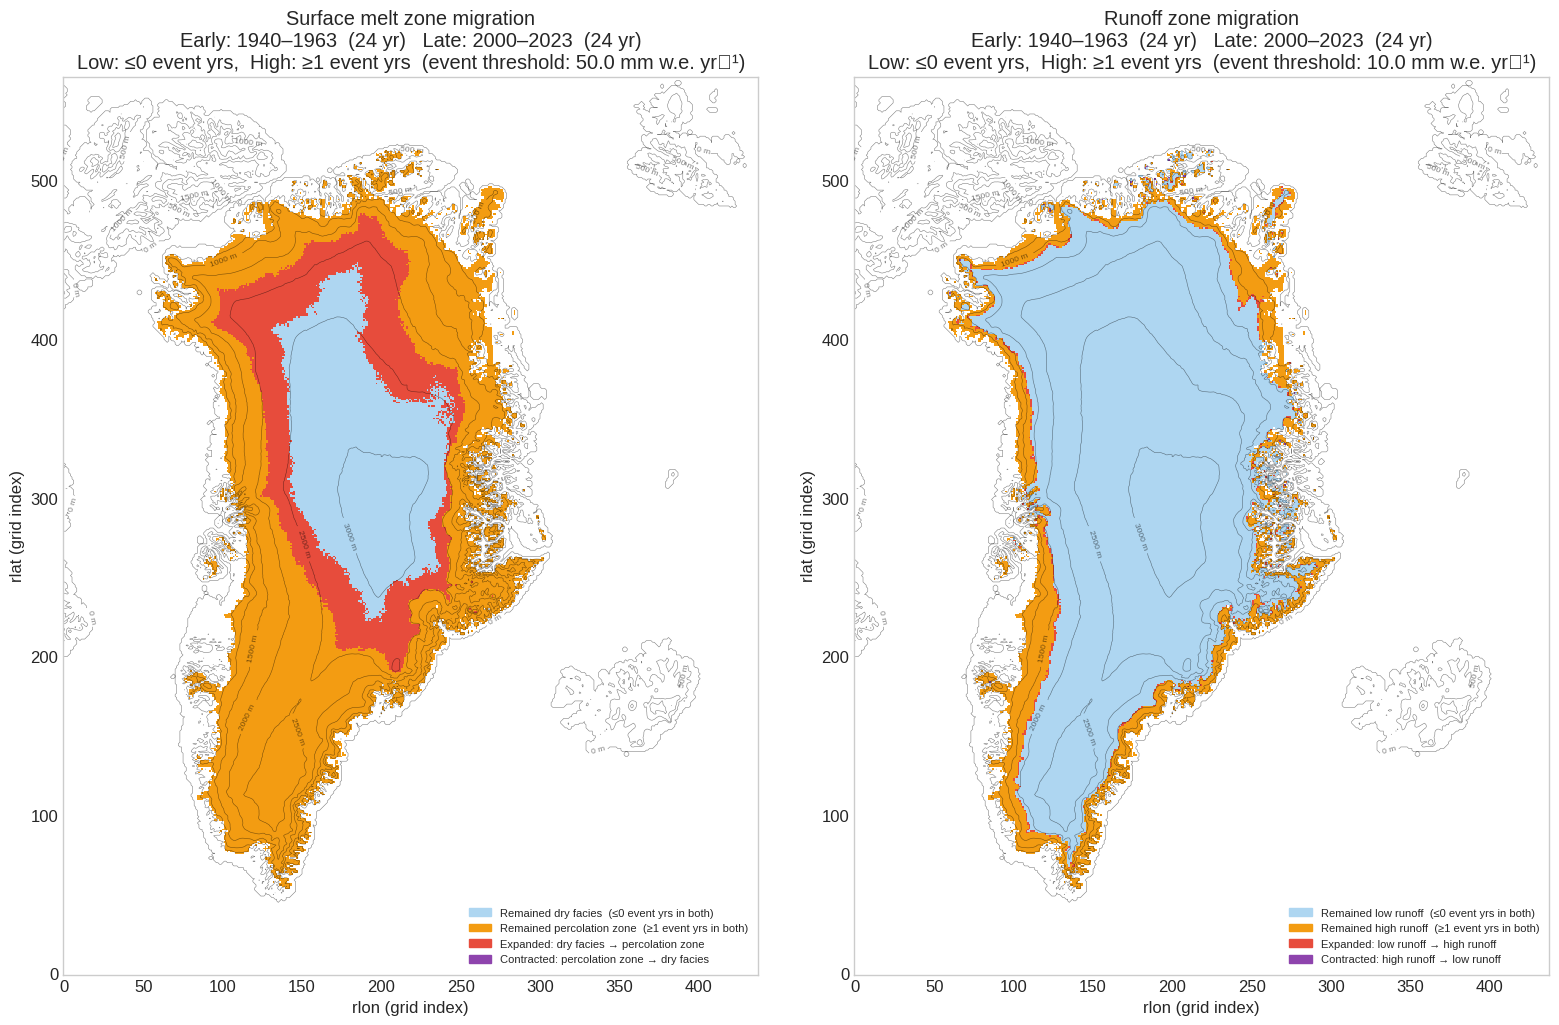

In [5]:
RUNOFF_THRESHOLD = 10.0
MELT_THRESHOLD = 50.0   # mm w.e. — cells above this are "high runoff zone"

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

plot_percolation_migration(variable='surfmelt', mode='events',
    threshold=MELT_THRESHOLD,
    percolation_events_min = 3,
    topo_contour_interval=500,
    ax=axes[0])
plot_percolation_migration(variable='Runoff', mode='events',
    threshold=RUNOFF_THRESHOLD, 
    topo_contour_interval=500,
    ax=axes[1])

plt.tight_layout()
plt.show()

---
## Firn memory

**Firn memory** is the time (in years) for a surface firn parcel to descend to a target
depth (default 10 m).  It is read directly from the `year` variable in the 2D Lagrangian
profile files, which records when each layer was originally deposited at the surface.

| Zone | Expected firn memory |
|------|----------------------|
| Dry-snow / accumulation zone | Long (decades–century): slow densification |
| Percolation zone | Variable: melt-refreeze speeds up densification |
| Ablation zone / thin firn | **NaN** — firn column does not reach 10 m |

The output is a gridded NetCDF `FDM_firn_memory_FGRN055_1939-2023_2D.nc` with a full
time series (1026 monthly timesteps) plus time-mean and temporal std.

> **Note:** `create_gridded_firn_memory()` loops over ~58 265 per-column 2D files.
> Run it as a batch job, not interactively.  The cell below submits it via subprocess.

In [ ]:
import subprocess, xarray as xr, numpy as np, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

from firn_analysis import create_gridded_firn_memory, compute_firn_memory_column
import config

FIRN_MEMORY_FILE = config.FIRN_MEMORY_FILE
OUTPUT_DIR       = Path(config.SCRATCH_DIR) / config.PROJECT_NAME / 'output'

print('Output file:', FIRN_MEMORY_FILE)
print('Exists:     ', FIRN_MEMORY_FILE.exists())

In [11]:
# ── Quick sanity check on a single column before running the full batch ──
# K-transect site at ~1542 m elevation (file 8841)
import netCDF4 as nc

test_file = OUTPUT_DIR / 'FGRN055_era055_2D_8841.nc'
ref       = xr.open_dataset(config.Z830_FILE, decode_times=False)
time_arr  = ref['time'].values
ref.close()
time_sim  = time_arr - time_arr[0]

fm_test = compute_firn_memory_column(test_file, time_sim, target_depth=10.0)

print(f'File:   {test_file.name}')
print(f'n_time: {len(fm_test)}')
print(f'First 5 values (firn memory in years): {np.round(fm_test[:5], 1)}')
print(f'Last  5 values: {np.round(fm_test[-5:], 1)}')
print(f'NaN fraction:   {np.isnan(fm_test).mean():.2%}')
print(f'Mean (non-NaN): {np.nanmean(fm_test):.1f} years')

File:   FGRN055_era055_2D_8841.nc
n_time: 1026
First 5 values (firn memory in years): [nan nan nan nan nan]
Last  5 values: [nan nan nan nan nan]
NaN fraction:   100.00%
Mean (non-NaN): nan years


/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.1259740.20260304_050323.230/ipykernel_3287030/1505559548.py:18: RuntimeWarning: Mean of empty slice
  print(f'Mean (non-NaN): {np.nanmean(fm_test):.1f} years')


In [ ]:
# ── Run the full batch (submit as a job if this cell takes too long) ──
# Uncomment and run when ready.  Expect ~30–90 min depending on NFS speed.
# result = create_gridded_firn_memory(
#     'FDM_firn_memory_FGRN055_1939-2023_2D.nc',
#     verbose=True,
# )

# Alternative: submit as a batch job
# subprocess.run(
#     ['sbatch', '--export=ALL,JOB=firn_memory',
#      str(Path('.') / 'jobs' / 'submit_batch.sh')],
#     check=True,
# )

print('Batch job not yet run.  Uncomment one of the calls above to produce the file.')

### Map: time-mean firn memory across Greenland

/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


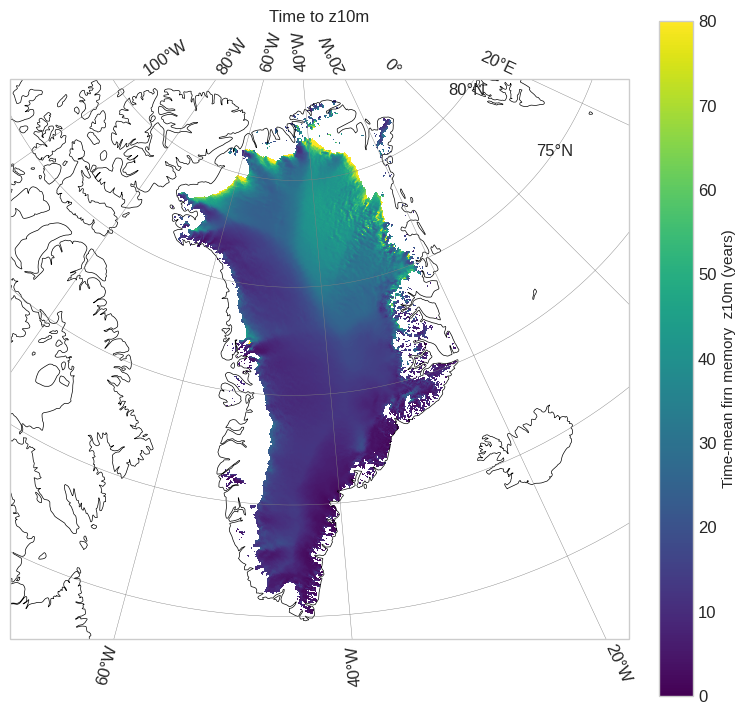

In [12]:
# ── Choose which firn memory diagnostic to plot ──────────────────────────────
# 'z10m'  →  firn_memory_mean      (time for a surface layer to reach 10 m)
# 'z830'  →  firn_memory_z830_mean (time for a surface layer to reach 830 kg/m³)
FIRN_VAR = 'z10m'   # ← change to 'z830' to plot the firn–ice transition metric

_var_map = {
    'z10m': ('firn_memory_mean',      'Time-mean firn memory  z10m (years)',  0,  80),
    'z830': ('firn_memory_z830_mean', 'Time-mean firn memory  z830 (years)',  0, 300),
}
nc_var, cbar_label, vmin, vmax = _var_map[FIRN_VAR]

ds_fm   = xr.open_dataset(FIRN_MEMORY_FILE)
fm_data = ds_fm[nc_var].values.copy().astype(np.float32)
lat     = ds_fm['lat'].values
lon     = ds_fm['lon'].values
has_xy  = 'x' in ds_fm and 'y' in ds_fm
if has_xy:
    x = ds_fm['x'].values
    y = ds_fm['y'].values
ds_fm.close()

# For z830: spin-up artefacts are stored as -9999 → treat as NaN
if FIRN_VAR == 'z830':
    fm_data = np.where(fm_data == -9999.0, np.nan, fm_data)

# ── Plot ──────────────────────────────────────────────────────────────────────
native_crs = ccrs.Stereographic(
    central_latitude=90, central_longitude=-45, true_scale_latitude=70
)
fig, ax = plt.subplots(
    figsize=(8, 10),
    subplot_kw={'projection': native_crs},
)

if has_xy:
    pcm = ax.pcolormesh(x, y, fm_data, transform=native_crs,
                        cmap='viridis', vmin=vmin, vmax=vmax)
else:
    pcm = ax.pcolormesh(lon, lat, fm_data, transform=ccrs.PlateCarree(),
                        cmap='viridis', vmin=vmin, vmax=vmax)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
ax.set_extent([-70, -15, 59, 84], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linewidth=0.3, color='grey')

cb = plt.colorbar(pcm, ax=ax, shrink=0.7, pad=0.04)
cb.set_label(cbar_label, fontsize=11)
ax.set_title(f'Time to {FIRN_VAR}', fontsize=12)

plt.tight_layout()
plt.show()

### Time series at K-transect example points

Three points along the K-transect (west Greenland) spanning the transition from
percolation zone to dry-snow zone.

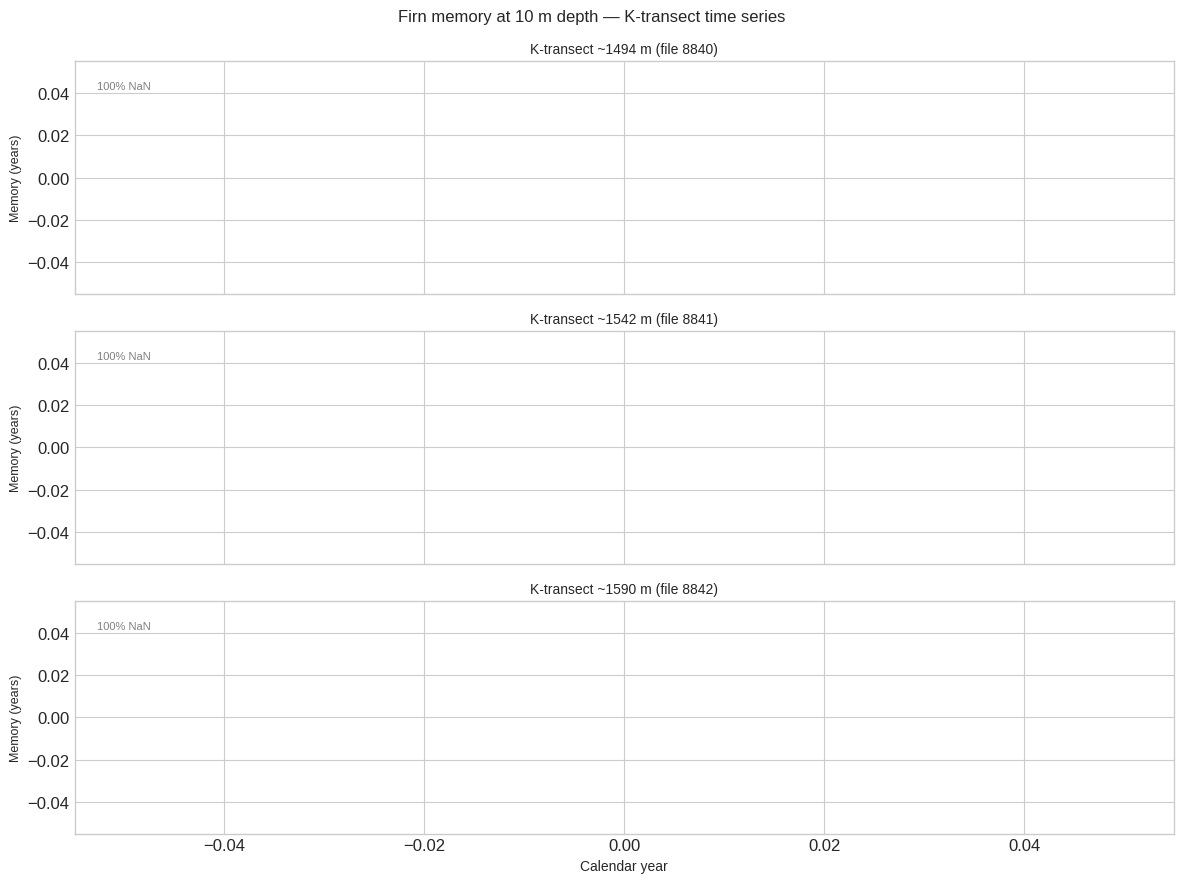

In [7]:
# K-transect sites: file number, approximate elevation
K_TRANSECT = {
    '~1494 m (file 8840)': 8840,
    '~1542 m (file 8841)': 8841,
    '~1590 m (file 8842)': 8842,
}

ref      = xr.open_dataset(config.Z830_FILE, decode_times=False)
time_arr = ref['time'].values   # fractional calendar year
ref.close()
time_sim = time_arr - time_arr[0]

fig, axes = plt.subplots(len(K_TRANSECT), 1, figsize=(12, 9), sharex=True)

for ax, (label, file_num) in zip(axes, K_TRANSECT.items()):
    nc_file = OUTPUT_DIR / f'FGRN055_era055_2D_{file_num}.nc'
    fm = compute_firn_memory_column(nc_file, time_sim, target_depth=10.0)
    ax.plot(time_arr, fm, lw=0.8, color='steelblue')
    ax.set_ylabel('Memory (years)', fontsize=9)
    ax.set_title(f'K-transect {label}', fontsize=10)
    nan_frac = np.isnan(fm).mean()
    if nan_frac > 0:
        ax.annotate(f'{nan_frac:.0%} NaN', xy=(0.02, 0.88),
                    xycoords='axes fraction', fontsize=8, color='grey')

axes[-1].set_xlabel('Calendar year', fontsize=10)
fig.suptitle('Firn memory at 10 m depth — K-transect time series', fontsize=12)
plt.tight_layout()
plt.show()

---
## Firn ice content — K-transect test

Integrated ice content (kg m⁻²) within the firn column above the firn–ice transition,
computed from the 2D monthly files for the 62 K-transect line points.

This is a quick verification that `compute_firn_ice_content_column` works correctly
before running the full gridded batch job.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from pathlib import Path

from firn_analysis import compute_firn_ice_content_column, compute_firn_thickness_column
import config

OUTPUT_DIR   = Path(config.SCRATCH_DIR) / config.PROJECT_NAME / 'output'
POINTLIST    = Path('/home/nld4814/perm/code/IMAU-FDM/rundir/pointlists/pointlist_k_transect_line.txt')
MASTER_PL    = Path('/home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/IN_ll_FGRN055.txt')
SAVE_FILE    = config.PROCESSED_DIR / 'FDM_firn_ice_content_k_transect_line.nc'
RERUN = False  # set True to force recomputation even if save file exists


# Load time axis
ref      = xr.open_dataset(config.Z830_FILE, decode_times=False)
time_arr = ref['time'].values
ref.close()

# Load k-transect file numbers and look up metadata from master pointlist
file_nums = [int(l) for l in POINTLIST.read_text().split() if l.strip()]
master    = pd.read_csv(MASTER_PL, header=None, sep=',',
                        names=['lon', 'lat', 'c2', 'c3', 'c4', 'rlat_idx', 'rlon_idx'],
                        skipinitialspace=True)
pts = master.iloc[[fn - 1 for fn in file_nums]].reset_index(drop=True)

if SAVE_FILE.exists() and not RERUN:
    print(f'Save file already exists — skipping computation.\nLoad it in the next cell.')
else:
    # Compute FIC and firn thickness for each column
    fic_all, fth_all, file_nums_ok, errors = [], [], [], []
    for fn in file_nums:
        fpath = OUTPUT_DIR / f'FGRN055_era055_2D_{fn}.nc'
        if not fpath.exists():
            errors.append(fn); continue
        try:
            fic_all.append(compute_firn_ice_content_column(fpath))
            fth_all.append(compute_firn_thickness_column(fpath))
            file_nums_ok.append(fn)
        except Exception as e:
            print(f'  ERROR file {fn}: {e}')
            errors.append(fn)

    fic_arr = np.array(fic_all)   # (n_pts, n_time)
    fth_arr = np.array(fth_all)   # (n_pts, n_time)
    pts_ok  = master.iloc[[fn - 1 for fn in file_nums_ok]].reset_index(drop=True)
    print(f'Processed {len(fic_arr)}/{len(file_nums)} columns  ({len(errors)} errors)')

    ds = xr.Dataset(
        {
            'firn_ice_content': xr.DataArray(
                fic_arr, dims=('point', 'time'),
                attrs={'long_name': 'Integrated firn ice content', 'units': 'kg m-2',
                       'description': 'NaN = all-ice/no column; 0 = firn present, no embedded ice'}),
            'firn_thickness': xr.DataArray(
                fth_arr, dims=('point', 'time'),
                attrs={'long_name': 'Total firn thickness', 'units': 'm',
                       'description': 'NaN = no firn; sum of dz for layers with density < ICE_DENSITY'}),
        },
        coords={
            'time':     xr.DataArray(time_arr,
                            attrs={'long_name': 'time', 'units': 'fractional calendar year'}),
            'file_num': xr.DataArray(np.array(file_nums_ok, dtype=np.int32), dims=('point',),
                            attrs={'long_name': '1-based file number in master pointlist'}),
            'lon':      xr.DataArray(pts_ok['lon'].values, dims=('point',),
                            attrs={'units': 'degrees_east'}),
            'lat':      xr.DataArray(pts_ok['lat'].values, dims=('point',),
                            attrs={'units': 'degrees_north'}),
        },
        attrs={'title': 'IMAU-FDM firn ice content — K-transect line',
               'source': 'firn_analysis.compute_firn_ice_content_column'},
    )
    SAVE_FILE.unlink(missing_ok=True)  # avoid NFS append-mode locking
    ds.to_netcdf(SAVE_FILE)
    print(f'Saved: {SAVE_FILE}')
    # Expose same variables as load cell so plot cell works without re-loading
    fic_all   = fic_arr
    fth_all   = fth_arr
    lons_ok   = pts_ok['lon'].values
    file_nums = file_nums_ok
    pts       = pts_ok.copy()


Processed 62/62 columns  (0 errors)
Saved: /home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_firn_ice_content_k_transect_line.nc


In [8]:
# ── Load saved FIC + firn thickness for K-transect line ─────────────────────
SAVE_FILE = config.PROCESSED_DIR / 'FDM_firn_ice_content_k_transect_line.nc'

ds        = xr.open_dataset(SAVE_FILE)
fic_all   = ds['firn_ice_content'].values   # (n_pts, n_time)  kg m⁻²
fth_all   = ds['firn_thickness'].values     # (n_pts, n_time)  m
time_arr  = ds['time'].values
file_nums = ds['file_num'].values.tolist()
lons_ok   = ds['lon'].values
pts       = pd.DataFrame({'lon': ds['lon'].values, 'lat': ds['lat'].values,
                           'file_num': ds['file_num'].values})
ds.close()
print(f'Loaded {len(file_nums)} columns from {SAVE_FILE.name}')


Loaded 62 columns from FDM_firn_ice_content_k_transect_line.nc


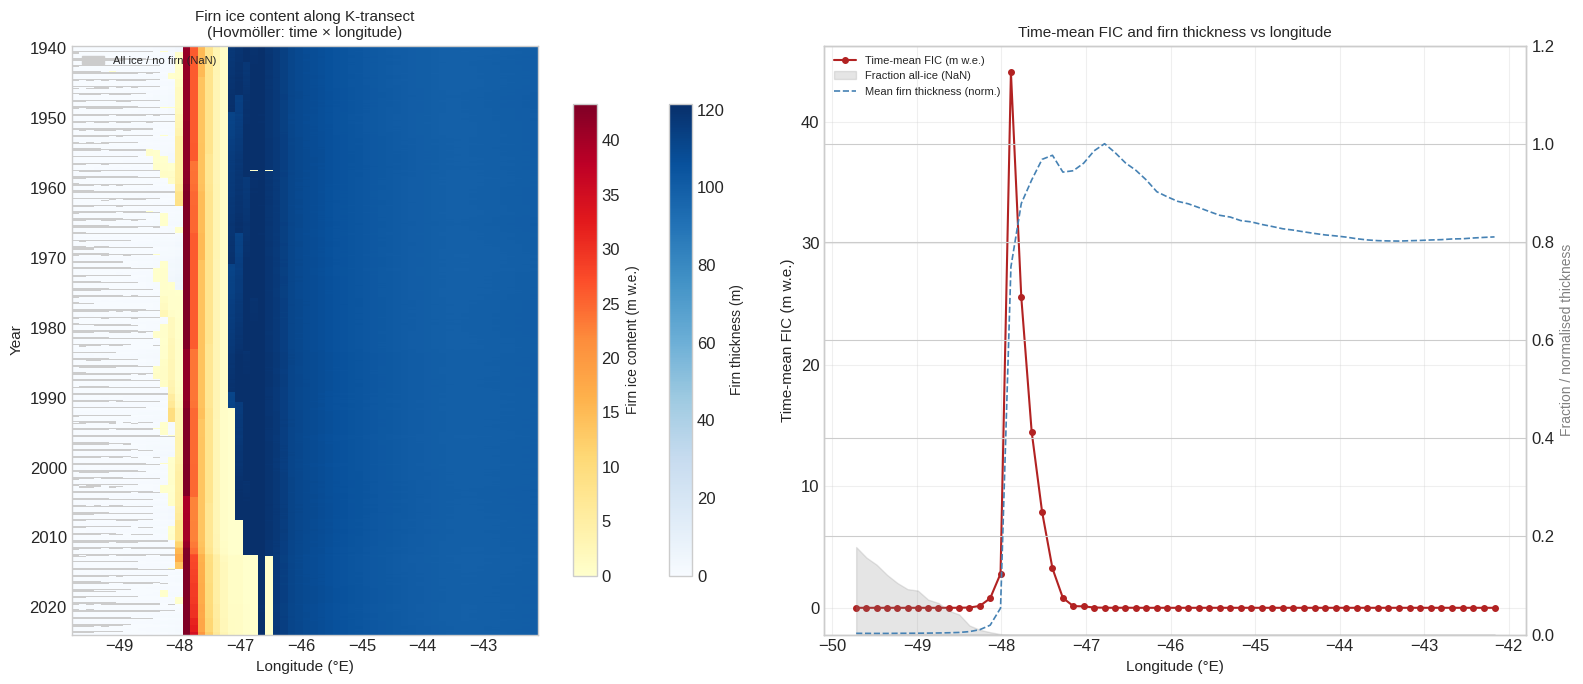

In [9]:
# ── Plot 1: Hovmöller — FIC vs time × longitude ───────────────────────────────
# Background: firn thickness (Blues — darker = thicker firn; grey = all ice / NaN)
# Overlay:    firn ice content > 0 (YlOrRd)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

fic_mwe  = fic_all / 1000.0             # kg/m² → m w.e.
lon_sort = np.argsort(lons_ok)
fic_s    = fic_mwe[lon_sort]            # (n_pts_sorted, n_time)
fth_s    = fth_all[lon_sort]            # firn thickness (m)
lons_s   = lons_ok[lon_sort]

has_ice = fic_s > 0

ax = axes[0]
ax.set_facecolor('#cccccc')            # grey background = all ice (NaN)

# Background: firn thickness in Blues (NaN stays grey)
fth_vmax = np.nanpercentile(fth_s, 95)
pcm_fth = ax.pcolormesh(lons_s, time_arr, fth_s.T,
                         cmap='Blues', vmin=0, vmax=fth_vmax,
                         shading='nearest')
cb_fth = plt.colorbar(pcm_fth, ax=ax, shrink=0.8, pad=0.01)
cb_fth.set_label('Firn thickness (m)', fontsize=10)

# Overlay: ice content in YlOrRd
vmax = max(np.nanpercentile(fic_s[has_ice], 95) if has_ice.any() else 1.0, 0.01)
ice_disp = np.where(has_ice, fic_s, np.nan)
pcm_fic = ax.pcolormesh(lons_s, time_arr, ice_disp.T,
                          cmap='YlOrRd', vmin=0, vmax=vmax,
                          shading='nearest')
cb_fic = plt.colorbar(pcm_fic, ax=ax, shrink=0.8, pad=0.06)
cb_fic.set_label('Firn ice content (m w.e.)', fontsize=10)

import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color='#cccccc', label='All ice / no firn (NaN)')],
          loc='upper left', fontsize=8, framealpha=0.85)

ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.set_title('Firn ice content along K-transect\n(Hovmöller: time × longitude)', fontsize=11)
ax.invert_yaxis()

# Right: time-mean FIC and time-mean firn thickness vs longitude
ax2 = axes[1]
fic_mean  = np.nanmean(fic_mwe, axis=1)
fth_mean  = np.nanmean(fth_all,  axis=1)
nan_frac  = np.isnan(fic_mwe).mean(axis=1)

ax2b = ax2.twinx()
ax2b.fill_between(lons_ok[lon_sort], nan_frac[lon_sort], alpha=0.2, color='grey',
                  label='Fraction all-ice (NaN)')
ax2b.plot(lons_ok[lon_sort], fth_mean[lon_sort] / fth_mean[lon_sort[np.nanargmax(fth_mean[lon_sort])]],
          '--', color='steelblue', lw=1.2, label='Mean firn thickness (norm.)')
ax2b.set_ylabel('Fraction / normalised thickness', fontsize=10, color='grey')
ax2b.set_ylim(0, 1.2)

ax2.plot(lons_ok[lon_sort], fic_mean[lon_sort], 'o-', color='firebrick', ms=4, zorder=5,
         label='Time-mean FIC (m w.e.)')
ax2.set_xlabel('Longitude (°E)', fontsize=11)
ax2.set_ylabel('Time-mean FIC (m w.e.)', fontsize=11)
ax2.set_title('Time-mean FIC and firn thickness vs longitude', fontsize=11)
ax2.grid(True, alpha=0.3)

lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


---
## Runoff limit analysis

The **runoff limit (RL)** for a given year is the highest topographic elevation at which
the annual total runoff ≥ a threshold.  Above the RL, essentially all melt refreezes in
the firn; below it, at least some melt escapes.

Four analyses are provided:

| Panel | Function | What it shows |
|---|---|---|
| a – time series | `compute_runoff_limit_timeseries` | Annual RL elevation 1939–2023, with MODIS / MAR benchmarks |
| a – map | `map_runoff_limit` | Mean annual runoff map with mean RL elevation contoured |
| b – map | `map_melt_above_limit_ice_lens` | Mean melt above the RL in cells where ice lenses are present |
| c – map | `map_ice_lens_summary` | Ice lens frequency and mean thickness across Greenland |
| d – scatter | `plot_lens_vs_melt` | Per-year mean ice lens thickness vs mean melt above the RL |

In [6]:
from runoff_limit_analysis import (
    compute_runoff_limit_timeseries,
    map_runoff_limit,
    map_melt_above_limit_ice_lens,
    map_ice_lens_summary,
    plot_lens_vs_melt,
)

import numpy as np

# Default runoff threshold (mm w.e./yr) — cells above this are "runoff producers"
RUNOFF_THRESHOLD = 10.0

# Check required files
_rl_files = {
    'Runoff':   config.VARIABLE_FILES['Runoff'],
    'surfmelt': config.VARIABLE_FILES['surfmelt'],
    'ice lens': config.ICE_LENS_FILE,
    'masks':    config.MASKS_FILE,
}
for label, fpath in _rl_files.items():
    status = '✓' if fpath.exists() else '✗  NOT FOUND'
    print(f'  [{status}]  {label:12s}  {fpath}')

  [✓]  Runoff        /home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_Runoff_FGRN055_1939-2023_10day.nc
  [✓]  surfmelt      /home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_surfmelt_FGRN055_1939-2023_10day.nc
  [✓]  ice lens      /home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process/FDM_ice_lens_FGRN055_1939-2023_2Ddetail.nc
  [✓]  masks         /home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/FGRN055_Masks.nc


### a) Runoff limit elevation — annual time series

Annual maximum topographic elevation of any ice-sheet cell that produced runoff
≥ `RUNOFF_THRESHOLD`.  Grey bands show MODIS (1613 ± 99 m) and MAR (1816 ± 94 m)
multi-year mean runoff limits from Machguth et al. 2026.

Mean RL 1940–2023 : 1908 m a.s.l.
Trend             : +0.7 m/yr


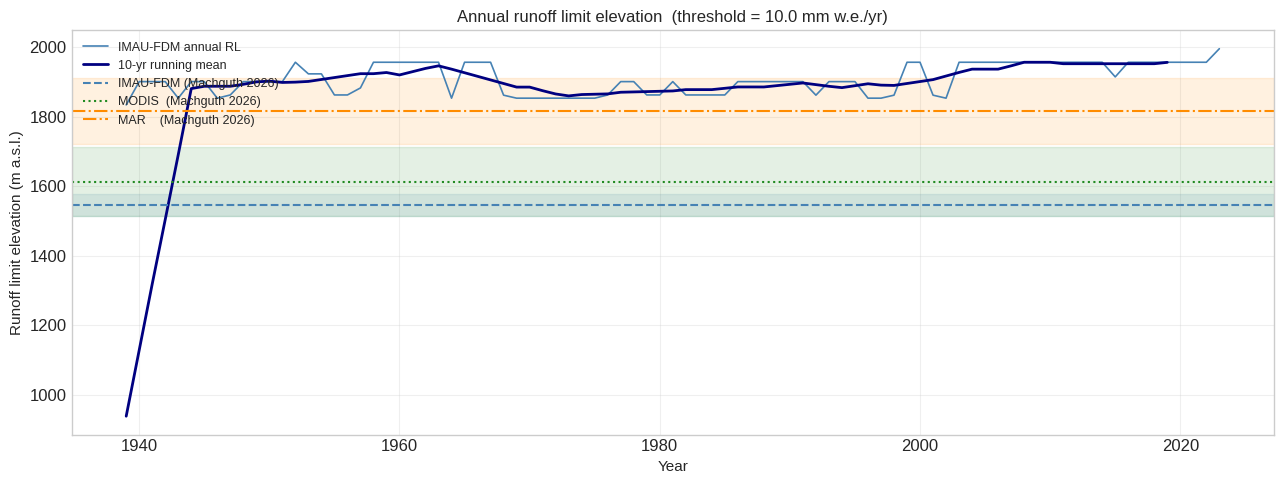

In [7]:
years_rl, rl_elev = compute_runoff_limit_timeseries(runoff_threshold=RUNOFF_THRESHOLD)

fig, ax = plt.subplots(figsize=(13, 5))

# IMAU-FDM annual RL
ax.plot(years_rl, rl_elev, color='steelblue', lw=1.2, label='IMAU-FDM annual RL')

# 10-year running mean
_win = 10
_rl_s = np.convolve(np.where(np.isfinite(rl_elev), rl_elev, np.nan),
                    np.ones(_win) / _win, mode='same')
ax.plot(years_rl, _rl_s, color='navy', lw=2.0, label=f'{_win}-yr running mean')

# Machguth et al. 2026 benchmarks (mean ± 1σ)
_benchmarks = {
    'IMAU-FDM (Machguth 2026)': (1545, 31,  'steelblue', '--'),
    'MODIS  (Machguth 2026)':   (1613, 99,  'forestgreen', ':'),
    'MAR    (Machguth 2026)':   (1816, 94,  'darkorange', '-.'),
}
for blabel, (bmean, bstd, bcol, bls) in _benchmarks.items():
    ax.axhspan(bmean - bstd, bmean + bstd, alpha=0.12, color=bcol)
    ax.axhline(bmean, color=bcol, lw=1.5, linestyle=bls, label=blabel)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Runoff limit elevation (m a.s.l.)', fontsize=11)
ax.set_title(f'Annual runoff limit elevation  (threshold = {RUNOFF_THRESHOLD} mm w.e./yr)', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

print(f'Mean RL 1940–2023 : {np.nanmean(rl_elev):.0f} m a.s.l.')
print(f'Trend             : {np.polyfit(years_rl[np.isfinite(rl_elev)], rl_elev[np.isfinite(rl_elev)], 1)[0]:+.1f} m/yr')

plt.tight_layout()
plt.show()

### a) Map: mean annual runoff with mean RL contour

Cells are coloured by their mean annual runoff (log scale).
The dashed navy contour marks the mean runoff limit elevation.

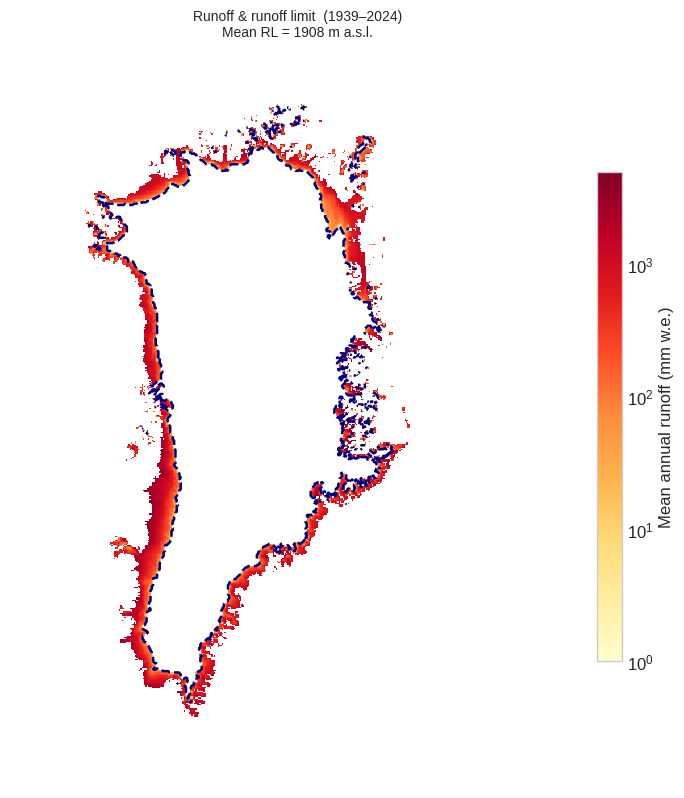

Mean runoff limit : 1908 m a.s.l.


In [8]:
(fig, ax), mean_rl = map_runoff_limit(runoff_threshold=RUNOFF_THRESHOLD)
plt.tight_layout()
plt.show()
print(f'Mean runoff limit : {mean_rl:.0f} m a.s.l.')

### b) Map: melt above the runoff limit where ice lenses are present

Shows the mean annual surface melt at cells that satisfy **all three** conditions each year:
- topographic elevation > that year's runoff limit,
- on the Greenland ice sheet,
- at least one 10-day timestep in that year has an ice lens detected.

This highlights the transition zone where percolating melt is intercepted by ice structures
but is not yet captured as runoff.

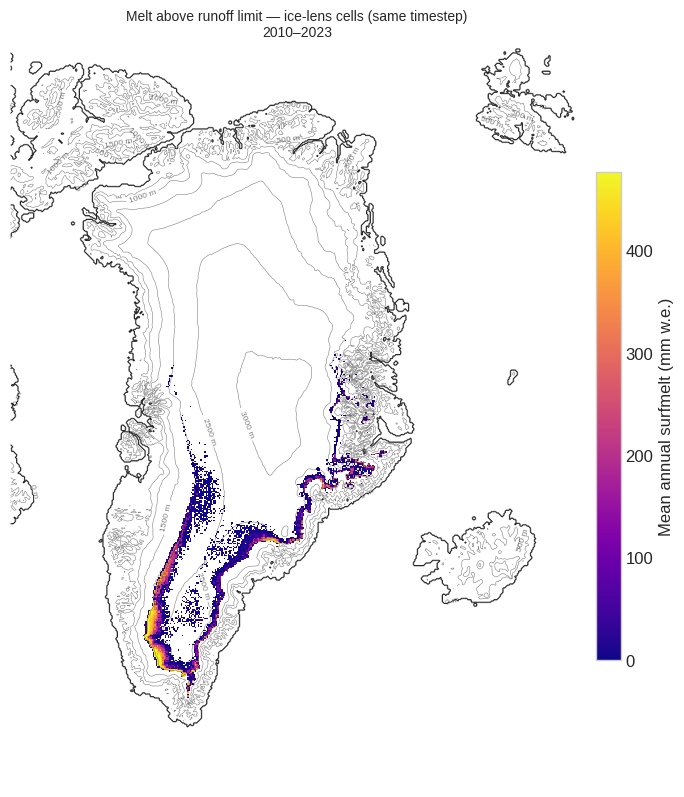

In [18]:
fig, ax = map_melt_above_limit_ice_lens(year_range=(2010,2023),runoff_threshold=RUNOFF_THRESHOLD)
plt.tight_layout()
plt.show()

### c) Map: ice lens / slab presence and thickness

Two-panel map showing:
- **Left** — fraction of all 10-day timesteps (1939–2023) where an ice lens is detected
  (`has_ice_lens = 1`).
- **Right** — mean ice lens thickness during steps when a lens is present.

A "lens" here is defined as a layer with density ≥ 900 kg/m³ sitting above at least one
layer below it with density < 900 kg/m³ (embedded in permeable firn).  The `require_firn_above`
flag was set to `True` in `create_gridded_ice_lens_file()`, so superimposed ice at the
very surface is excluded.

/etc/ecmwf/nfs/dh1_perm_b/nld4814/code/IMAU-FDM/research/runoff_limit_analysis.py:407: RuntimeWarning: invalid value encountered in divide
  ax_freq.set_aspect('equal')


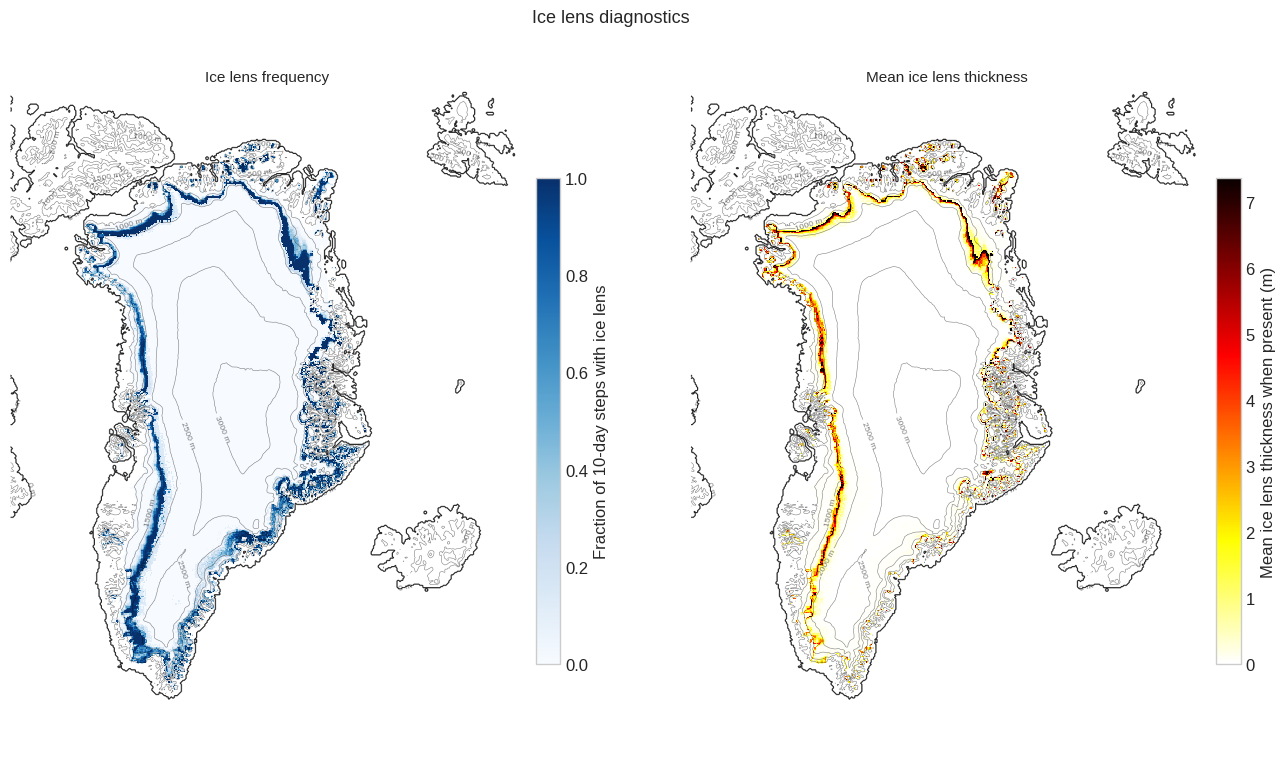

In [16]:
fig, (ax_freq, ax_thick) = map_ice_lens_summary()
plt.show()

### d) Ice lens thickness vs melt above the runoff limit

Each point is one calendar year.  For that year, only cells **above the annual runoff limit**
on the Greenland ice sheet are included.  The x-axis shows the spatially averaged annual
surface melt in those cells; the y-axis shows the mean ice lens thickness (averaged only over
steps when a lens is actually present).  Points are coloured by year.

/etc/ecmwf/nfs/dh1_perm_b/nld4814/code/IMAU-FDM/research/runoff_limit_analysis.py:514: RuntimeWarning: Mean of empty slice
  


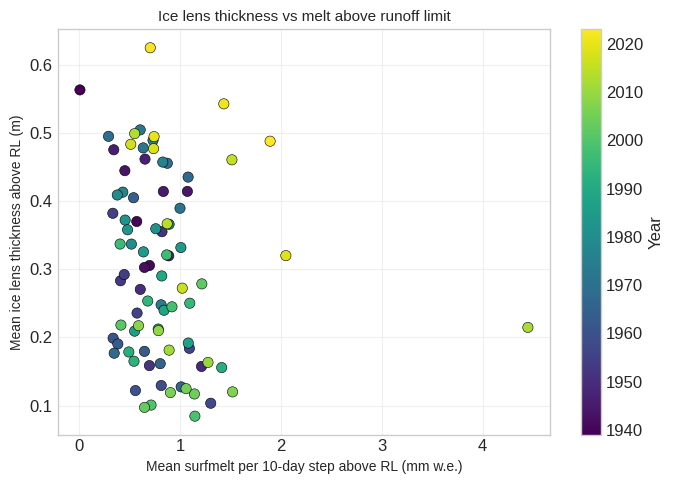

In [20]:
fig, ax = plot_lens_vs_melt(runoff_threshold=RUNOFF_THRESHOLD, melt_stat="mean")
plt.tight_layout()
plt.show()

---
## K-transect study area — grid point selection

Grid points from the FGRN055 master pointlist that fall within the K-transect study area polygon, and the continuous west→east transect row used for column-level analyses.

- **Area pointlist** (`IN_ll_FGRN055_k_transect.txt`): all ~4 070 FGRN055 points inside the polygon
- **Transect line** (`IN_ll_FGRN055_k_transect_line.txt`): 62 consecutive points at rlat_idx 184 (~66.5°N), running from the coast (~-49.7°E) to the ice sheet interior (~-42.2°E)

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

RESEARCH_DIR     = Path('/home/nld4814/perm/code/IMAU-FDM/research')
POINTLISTS_DIR   = Path('/home/nld4814/perm/code/IMAU-FDM/rundir/pointlists')
MASTER_POINTLIST = Path('/home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/IN_ll_FGRN055.txt')
MASKS_FILE       = Path('/home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/FGRN055_Masks.nc')
K_TRANSECT_SHP   = RESEARCH_DIR / 'k_transect_study_area.shp'

# Load master pointlist once, then look up rows by 1-based file number
_cols  = ['lon', 'lat', 'c2', 'c3', 'c4', 'rlat_idx', 'rlon_idx']
master = pd.read_csv(MASTER_POINTLIST, header=None, sep=',',
                     names=_cols, skipinitialspace=True)

def _load_pts(path):
    """Read a pointlist of 1-based file indices and return the matching master rows."""
    idx = pd.read_csv(path, header=None, names=['file_num'])['file_num'].values
    return master.iloc[idx - 1].reset_index(drop=True)  # 1-based → 0-based iloc

area_pts = _load_pts(POINTLISTS_DIR / 'pointlist_k_transect_area.txt')
line_pts = _load_pts(POINTLISTS_DIR / 'pointlist_k_transect_line.txt')
k_area   = gpd.read_file(K_TRANSECT_SHP)

masks = xr.open_dataset(MASKS_FILE)
topo  = masks['Topography'].squeeze().values
lat2d = masks['lat'].values
lon2d = masks['lon'].values
masks.close()

# ── Map ─────────────────────────────────────────────────────────────────────
proj   = ccrs.NorthPolarStereo(central_longitude=-42)
extent = [-54, -39, 63.5, 69.5]

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(projection=proj))
ax.set_extent(extent, crs=ccrs.PlateCarree())

topo_masked = np.where(topo > 0, topo, np.nan)
cf = ax.contourf(lon2d, lat2d, topo_masked,
                 levels=np.arange(0, 2800, 200),
                 cmap='terrain', alpha=0.55,
                 transform=ccrs.PlateCarree())
ax.contour(lon2d, lat2d, topo_masked,
           levels=[500, 1000, 1500, 2000],
           colors='grey', linewidths=0.4, alpha=0.6,
           transform=ccrs.PlateCarree())
plt.colorbar(cf, ax=ax, shrink=0.7, pad=0.02, label='Elevation (m a.s.l.)')

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5, linestyle='--')
k_area.boundary.plot(ax=ax, color='black', linewidth=1.5, transform=ccrs.PlateCarree())

ax.scatter(area_pts['lon'], area_pts['lat'], s=3, c='steelblue', alpha=0.5,
           transform=ccrs.PlateCarree(), label=f'Study area pts (n={len(area_pts)})', zorder=4)
ax.scatter(line_pts['lon'], line_pts['lat'], s=18, c='crimson', zorder=5,
           transform=ccrs.PlateCarree(),
           label=f'Transect line (n={len(line_pts)}, rlat={int(line_pts["rlat_idx"].iloc[0])})')

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.5,
                  x_inline=False, y_inline=False)
gl.top_labels = gl.right_labels = False

ax.legend(loc='lower right', fontsize=9, framealpha=0.85)
ax.set_title('FGRN055 K-transect study area\ngrid point selection', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Area pts : {len(area_pts):5d}  |  lon {area_pts["lon"].min():.1f}° → {area_pts["lon"].max():.1f}°  |  lat {area_pts["lat"].min():.1f}° – {area_pts["lat"].max():.1f}°')
print(f'Transect : {len(line_pts):5d}  |  lon {line_pts["lon"].min():.2f}° → {line_pts["lon"].max():.2f}°  |  rlat_idx = {int(line_pts["rlat_idx"].iloc[0])}  (~{line_pts["lat"].mean():.1f}°N)')